# Chemical and elastic phase separation

I use the website’s dimensionless two-dimensional model, with periodic boundaries, unit mobility and unit gradient coefficient. Composition c is a conserved field. The bulk free-energy density is c²(1-c)². Its derivative contributes 2c(1-c)(1-2c) to chemical potential. The elastic coefficient B(k) is zero for the chemical example. The elastic example uses a homogeneous 2D constitutive model with zero mean stress; it is not a calibrated alloy or a plane-strain reduction of a 3D eigenstrain.

I write one part, test it, then continue. Run the cells in order. This short lesson checks the method; it does not replace the complete simulation or establish convergence.

**Using my code.** I permit free noncommercial teaching, learning and demonstrations with acknowledgment. Research (including academic research) and commercial use require my explicit written permission. Earlier MIT and GPL releases retain their existing permissions. Read the [code-use terms](https://saswataiith.github.io/files/CODE-USE-TERMS.txt). Request permission at saswata_at_msme.iith.ac.in. These terms apply to code; teaching text and figures have separate terms.


## 1. Create wave numbers and the initial field

I start with the chemical case. The grid spacing is one dimensionless length unit. I remove the mean of the deterministic perturbation so that the initial mean composition is exactly 0.5 to floating-point accuracy.

In [1]:
import numpy as np
n = 64
dt = 0.2
k = 2 * np.pi * np.fft.fftfreq(n)
kx, ky = np.meshgrid(k, k, indexing="ij")
k2 = kx**2 + ky**2
row, column = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")
noise = np.sin((row + 1) * 12.9898 + (column + 1) * 78.233) * 43758.5453
noise = 0.02 * (noise - np.floor(noise) - 0.5)
noise -= noise.mean()
initial = 0.5 + noise
assert abs(initial.mean() - 0.5) < 1e-12
assert k2[0, 0] == 0
print("Initial mean:", initial.mean())

Initial mean: 0.5


## 2. Write one update and test conservation

The gradient and elastic terms are implicit; the nonlinear bulk derivative is explicit. The zero Fourier mode is unchanged because k² is zero there. I check the mean and finite values after one update. These checks do not prove energy stability.

In [2]:
chemical_kernel = np.zeros_like(k2)
bulk_derivative = 2 * initial * (1 - initial) * (1 - 2 * initial)
numerator = np.fft.fft2(initial) - dt * k2 * np.fft.fft2(bulk_derivative)
denominator = 1 + dt * k2 * (k2 + chemical_kernel)
one_step = np.fft.ifft2(numerator / denominator).real
assert np.isfinite(one_step).all()
assert abs(one_step.mean() - initial.mean()) < 1e-12
print("Mean change after one update:", one_step.mean() - initial.mean())

Mean change after one update: -5.551115123125783e-17


## 3. Add the elastic kernel separately

I use the existing tested kernel rather than introducing a different formula in this notebook. C11, C12 and C44 are dimensionless elastic stiffnesses here. The dilatational eigenstrain is dimensionless. I check the isotropic limit, in which the nonzero-mode kernel has no angular dependence. I also check that zero misfit removes the elastic contribution. I symmetrize conjugate Fourier partners for a real field on an even grid.

In [3]:
from pathlib import Path
import importlib.util
source = Path("../phase_field.py")
if not source.exists():
    raise FileNotFoundError("Extract the download with its folder structure before running this cell.")
spec = importlib.util.spec_from_file_location("teaching_phase_field", source)
model = importlib.util.module_from_spec(spec)
spec.loader.exec_module(model)
angles = np.linspace(0, 2 * np.pi, 33)
isotropic = model.kernel(np.cos(angles), np.sin(angles), c11=4, c12=2, c44=1)
assert np.ptp(isotropic) < 1e-12
assert np.allclose(model.kernel(kx, ky, eigenstrain=0), 0)
elastic_kernel = model.kernel(kx, ky, c11=4, c12=2, c44=3, eigenstrain=0.2)
partner = (-np.arange(n)) % n
elastic_kernel = 0.5 * (elastic_kernel + elastic_kernel[np.ix_(partner, partner)])
assert np.isfinite(elastic_kernel).all()
print("Isotropic angular variation:", np.ptp(isotropic))

Isotropic angular variation: 3.3306690738754696e-16


## 4. Compare short evolutions with the same initial field

I advance both cases from identical fields for 50 steps. This is a short execution and conservation check. The complete program supplies longer runs and free-energy records. Timestep and spatial refinement are separate questions and have not been established by this notebook.

Final time: 10.0
Field RMS difference: 0.005861495207825775


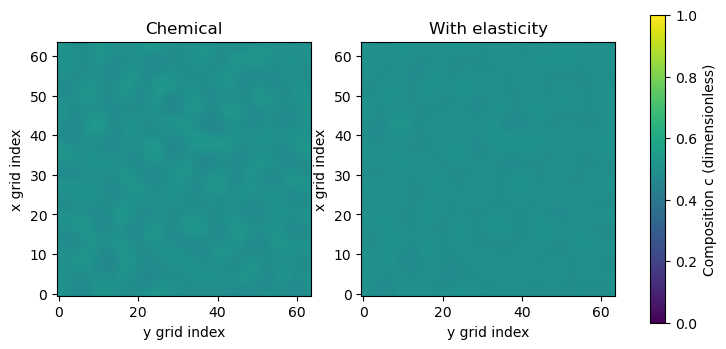

In [4]:
chemical = initial.copy()
elastic = initial.copy()
for step in range(50):
    chemical_bulk = 2 * chemical * (1 - chemical) * (1 - 2 * chemical)
    chemical_spectrum = np.fft.fft2(chemical) - dt * k2 * np.fft.fft2(chemical_bulk)
    chemical = np.fft.ifft2(chemical_spectrum / (1 + dt*k2*(k2 + chemical_kernel))).real
    elastic_bulk = 2 * elastic * (1 - elastic) * (1 - 2 * elastic)
    elastic_spectrum = np.fft.fft2(elastic) - dt * k2 * np.fft.fft2(elastic_bulk)
    elastic = np.fft.ifft2(elastic_spectrum / (1 + dt*k2*(k2 + elastic_kernel))).real
for result in (chemical, elastic):
    assert np.isfinite(result).all()
    assert abs(result.mean() - initial.mean()) < 1e-10
assert np.linalg.norm(chemical - elastic) > 0
print("Final time:", 50 * dt)
print("Field RMS difference:", np.sqrt(np.mean((chemical - elastic)**2)))

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, field, name in zip(axes, [chemical, elastic], ["Chemical", "With elasticity"]):
    image = ax.imshow(field, vmin=0, vmax=1, origin="lower")
    ax.set_title(name)
    ax.set_xlabel("y grid index")
    ax.set_ylabel("x grid index")
fig.colorbar(image, ax=axes, label="Composition c (dimensionless)")
plt.show()

## Continue with the complete program

The original complete program is `../phase_field.py`. Its parameters, source credits and output commands are retained. These short examples use smaller workloads for learning; they are not a rerun of every result on the website.